# Module 03: Your First Lens Model

## Learning to Autolens

---

**Purpose:** Learn the inverse problem: given observed data, recover the lens and source
parameters using Bayesian inference. This module introduces the modeling workflow —
setting up a model, defining priors, running a non-linear search, and interpreting
posteriors — which is the core of all lens modeling with PyAutoLens.

**Prerequisites:**
- Module 01 (Grids, Galaxies, Ray-Tracing)
- Module 02 (Simulating Lens Data)
- Basic Bayesian statistics (likelihood, prior, posterior)

**Key references:**
- Congdon & Keeton (2018), Ch. 8: *Modeling Lenses* (hereafter **C&K**)
- Nightingale, Dye & Massey (2018), Sec. 4–5 (hereafter **Nightingale+18**)
- Speagle (2020), *dynesty: a dynamic nested sampling package* (hereafter **Speagle20**)
- Skilling (2004), *Nested Sampling* (hereafter **Skilling04**)

**Companion Mathematica script:** `../../Mathematica/03_bayesian_inference_and_chi2.wl`

---

## Table of Contents

1. [The Inverse Problem: From Data to Parameters](#1-the-inverse-problem)
2. [Loading and Masking Data](#2-loading-and-masking-data)
3. [Building the Model with PyAutoFit](#3-building-the-model)
4. [Prior Customization](#4-prior-customization)
5. [The Non-Linear Search: Nautilus & Dynesty](#5-the-non-linear-search)
6. [Running the Fit](#6-running-the-fit)
7. [Interpreting Results: Posteriors and Diagnostics](#7-interpreting-results)
8. [Common Pitfalls and Degeneracies](#8-common-pitfalls)
9. [Exercises](#9-exercises)

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os
if os.environ.get("PYAUTOFIT_TEST_MODE"):
    raise RuntimeError(
        f"PYAUTOFIT_TEST_MODE={os.environ['PYAUTOFIT_TEST_MODE']!r} is set. "
        "PyAutoFit would skip sampling and return a random prior draw. "
        "Unset it and restart the kernel:  unset PYAUTOFIT_TEST_MODE"
    )

# autofit (af): the model-fitting framework that PyAutoLens
#   builds on. Provides af.Model, af.Collection, priors, and
#   non-linear search wrappers (Nautilus, Dynesty, Emcee).
# ============================================================

import autolens as al
import autolens.plot as aplt
import autofit as af

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

print(f"PyAutoLens version: {al.__version__}")
print(f"PyAutoFit version: {af.__version__}")

PyAutoLens version: 2026.2.26.4
PyAutoFit version: 2026.2.26.4


---

## 1. The Inverse Problem: From Data to Parameters <a id="1-the-inverse-problem"></a>

### Theory: Bayesian Lens Modeling

In Module 02, we learned the **forward model**:

$$
\mathbf{d} = \text{PSF} * \mathbf{I}(\boldsymbol{\eta}) + \mathbf{n}
$$

where $\boldsymbol{\eta}$ are the model parameters (lens mass, source light, etc.).

The **inverse problem** asks: given the data $\mathbf{d}$, what are the parameters
$\boldsymbol{\eta}$? Bayesian inference gives us the answer via **Bayes' theorem**:

$$
P(\boldsymbol{\eta} | \mathbf{d}) = \frac{\mathcal{L}(\mathbf{d} | \boldsymbol{\eta}) \, \pi(\boldsymbol{\eta})}{\mathcal{Z}}
$$

where:
- $P(\boldsymbol{\eta} | \mathbf{d})$ = the **posterior**: probability of parameters given data
- $\mathcal{L}(\mathbf{d} | \boldsymbol{\eta})$ = the **likelihood**: how well parameters reproduce the data
- $\pi(\boldsymbol{\eta})$ = the **prior**: what we know before seeing the data
- $\mathcal{Z} = \int \mathcal{L} \, \pi \, d\boldsymbol{\eta}$ = the **evidence**: model comparison metric

### The Likelihood for Imaging Data

For Gaussian noise (valid when photon counts are large), the log-likelihood is
(Nightingale+18 eq. 3; C&K eq. 8.7):

$$
\ln \mathcal{L} = -\frac{1}{2} \sum_i \left[ \frac{(d_i - m_i)^2}{\sigma_i^2} + \ln(2\pi\sigma_i^2) \right]
= -\frac{1}{2} \chi^2 + \text{const}
$$

where $d_i$ is the observed pixel value, $m_i$ is the model prediction (PSF-convolved
Tracer image), and $\sigma_i$ is the noise in pixel $i$.

The $\chi^2$ per degree of freedom should be $\approx 1$ for a good fit:
$\chi^2_{\rm red} = \chi^2 / N_{\rm dof}$ where $N_{\rm dof} = N_{\rm pixels} - N_{\rm params}$.

### Why Non-Linear Search?

The lens model is **non-linear** in the parameters (e.g., changing $\theta_E$ changes
which image pixels are illuminated in a non-smooth way). This means we can't solve
for the maximum likelihood analytically — we need to **search** the parameter space.

PyAutoLens supports several search algorithms:
- **Nautilus** (importance nested sampling): fast, robust — the default
- **Dynesty** (dynamic nested sampling): more established, flexible
- **Emcee** (MCMC): good for refining posteriors
- **LBFGS** (gradient descent): fast point estimate, no uncertainties

---

## 2. Loading and Masking Data <a id="2-loading-and-masking-data"></a>

### Why Masking?

We don't model every pixel in the image — we apply a **circular mask** to focus on
the region containing the lens and lensed arcs. This:
1. Reduces the number of pixels → faster likelihood evaluation
2. Excludes contaminating objects (nearby galaxies, stars)
3. Focuses the $\chi^2$ on the pixels that constrain the model

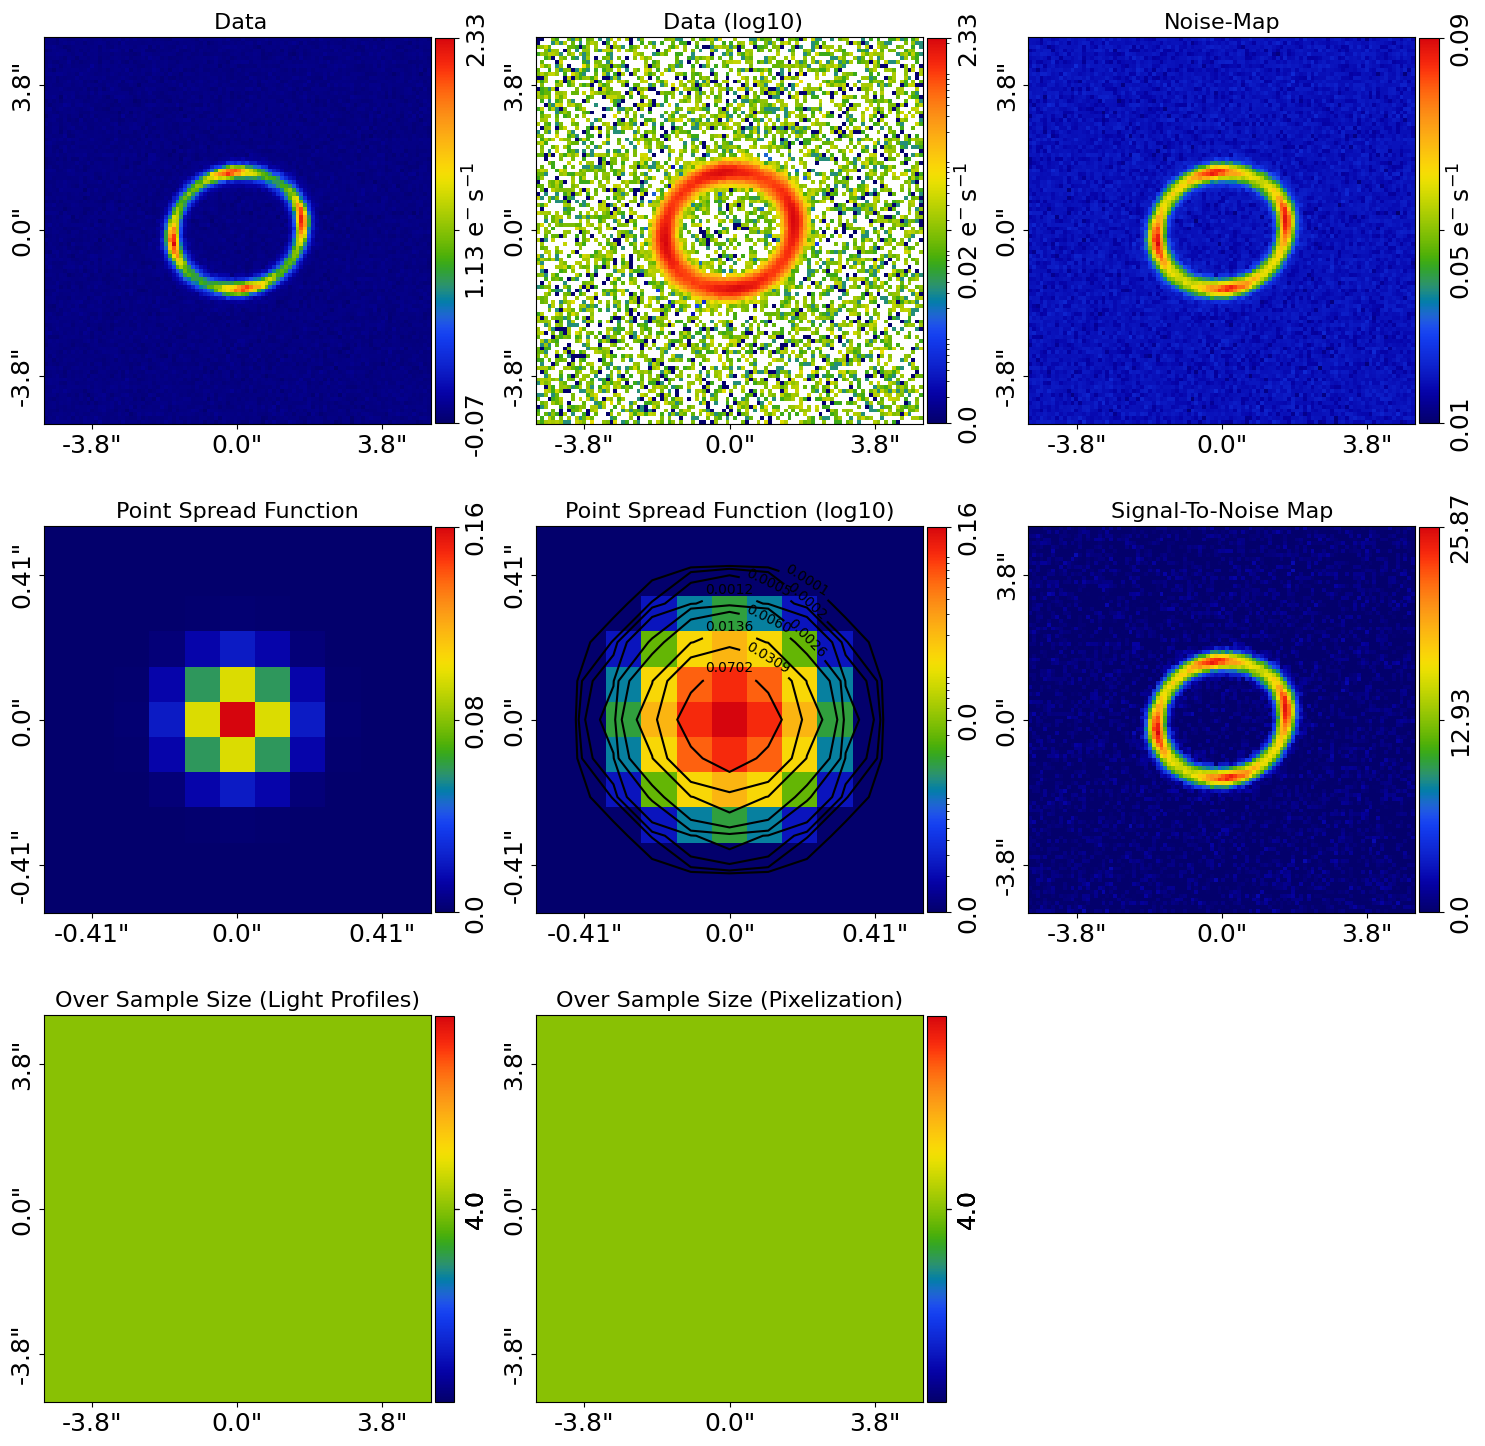

In [2]:
# ============================================================
# LOAD AN EXAMPLE DATASET
# ============================================================
# We use one of the built-in example datasets from the
# autolens_workspace. This is a simulated SIE lens with a
# Sersic source and no lens light (simplest case).
# ============================================================

dataset_name = "simple__no_lens_light"
dataset_path = Path(
    "../../autolens_workspace_original/dataset/imaging/simple__no_lens_light"
)

dataset = al.Imaging.from_fits(
    data_path=dataset_path / "data.fits",
    psf_path=dataset_path / "psf.fits",
    noise_map_path=dataset_path / "noise_map.fits",
    pixel_scales=0.1,
)

# Inspect the raw data
dataset_plotter = aplt.ImagingPlotter(dataset=dataset)
dataset_plotter.subplot_dataset()

2026-04-17 17:27:55,287 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 2828 image-pixels


Image shape: (100, 100)
Masked pixels: 2828 (of 10000 total)
Mask reduces computation by: 72%


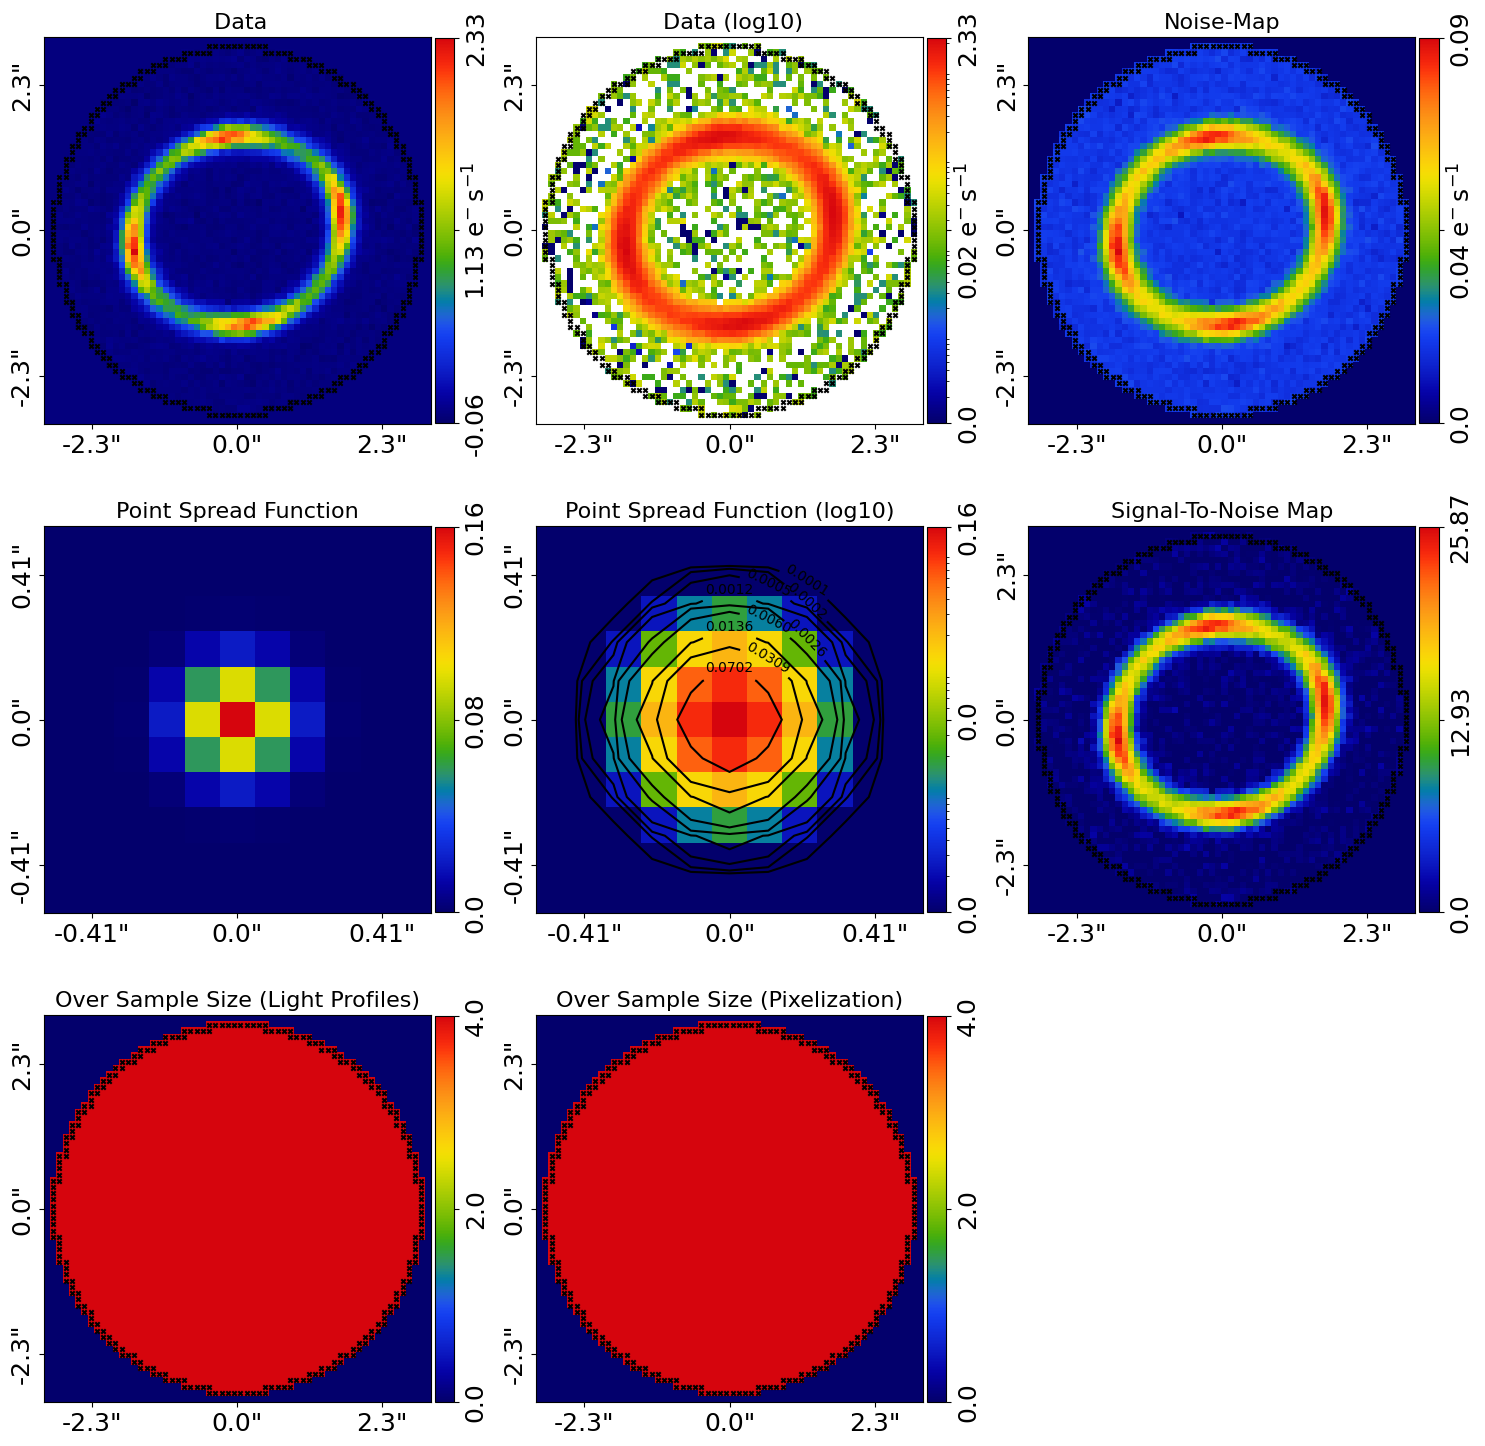

In [3]:
# ============================================================
# APPLY A CIRCULAR MASK
# ============================================================
# The mask radius should be large enough to include all lensed
# arcs but small enough to exclude irrelevant pixels.
#
# For a lens with θ_E ~ 1.6", a 3" radius mask comfortably
# encompasses the arcs (which extend to ~2× θ_E).
# ============================================================

mask = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=3.0,   # arcsec — includes all arcs for θ_E ~ 1.6"
)

dataset = dataset.apply_mask(mask=mask)

print(f"Image shape: {dataset.shape_native}")
print(f"Masked pixels: {dataset.data.shape_slim} (of {dataset.shape_native[0]**2} total)")
print(f"Mask reduces computation by: {1 - dataset.data.shape_slim / dataset.shape_native[0]**2:.0%}")

# Visualize the masked dataset
dataset_plotter = aplt.ImagingPlotter(dataset=dataset)
dataset_plotter.subplot_dataset()

---

## 3. Building the Model with PyAutoFit <a id="3-building-the-model"></a>

### The af.Model and af.Collection Framework

PyAutoLens uses **PyAutoFit** (`af`) for model construction. The key objects:

- `af.Model(ClassName)`: wraps a class (e.g., `al.mp.Isothermal`) and turns each
  constructor parameter into a **free parameter** with a prior
- `af.Collection(...)`: groups multiple models into a hierarchy

The model hierarchy for lens modeling is:
```
Collection
└── galaxies (Collection)
    ├── lens (Model → Galaxy)
    │   ├── mass (Model → Isothermal)
    │   └── shear (Model → ExternalShear)
    └── source (Model → Galaxy)
        └── bulge (Model → Sersic)
```

Each leaf parameter gets a **prior** (uniform, Gaussian, or log-uniform) that
defines the allowed range.

In [4]:
# ============================================================
# BUILD THE LENS MODEL
# ============================================================
# We start with a simple model: SIE mass + external shear for
# the lens, Sersic light for the source. No lens light (this
# dataset has the lens light removed).
#
# This gives us ~11 free parameters:
#   Lens mass (SIE): centre (2), ell_comps (2), einstein_radius (1)
#   Shear: gamma_1 (1), gamma_2 (1)
#   Source (Sersic): centre (2), ell_comps (2), intensity (1),
#                    effective_radius (1), sersic_index (1)
#   Total: 5 + 2 + 7 = 14 free parameters
#
# Note: af.Model(al.Galaxy, ...) creates a Galaxy model where
# redshift is FIXED (not a free parameter) and the profiles
# are free models.
# ============================================================

# Lens galaxy: mass + shear, no light
lens = af.Model(
    al.Galaxy,
    redshift=0.5,                          # Fixed redshift (known from spectroscopy)
    mass=al.mp.Isothermal,                 # SIE mass profile
    shear=al.mp.ExternalShear,             # External shear
)

# Source galaxy: light only, no mass
source = af.Model(
    al.Galaxy,
    redshift=1.0,                          # Fixed source redshift
    bulge=al.lp.SersicCore,                # Sersic light profile
)

# Combine into a model collection
model = af.Collection(
    galaxies=af.Collection(
        lens=lens,
        source=source,
    ),
)

# Inspect the model: see all free parameters and their default priors
print(model.info)

Total Free Parameters = 14

model                                                                           Collection (N=14)
    galaxies                                                                    Collection (N=14)
        lens - source                                                           Galaxy (N=7)
        lens
            mass                                                                Isothermal (N=5)
            shear                                                               ExternalShear (N=2)
        source
            bulge                                                               SersicCore (N=7)

galaxies
    lens
        redshift                                                                0.5
        mass
            centre
                centre_0                                                        GaussianPrior [0], mean = 0.0, sigma = 0.1
                centre_1                                                        GaussianPrior [1], mean

---

## 4. Prior Customization <a id="4-prior-customization"></a>

### Theory: Why Priors Matter

Priors encode our **physical knowledge** about the lens system. Good priors:
- Speed up the search by excluding unphysical regions
- Prevent the optimizer from finding non-physical local minima
- Reflect genuine constraints (e.g., Einstein radii of galaxy-scale lenses are 0.5"–3")

Bad priors can:
- Exclude the true solution → biased results
- Be too broad → slow convergence
- Be too narrow → overconfident posteriors

### PyAutoFit Prior Types

| Prior | Usage | Example |
|-------|-------|---------|
| `af.UniformPrior(lower, upper)` | Bounded range, no preference | Einstein radius: $[0.5, 3.0]$ |
| `af.GaussianPrior(mean, sigma)` | Peaked around expected value | Centre: $\mathcal{N}(0, 0.1)$ |
| `af.LogUniformPrior(lower, upper)` | Scale-invariant (spans orders of magnitude) | Intensity: $[10^{-3}, 10^3]$ |

In [5]:
# ============================================================
# CUSTOMIZE PRIORS
# ============================================================
# We tighten the default priors using physical knowledge.
#
# Key insight: the lens centre should be near the image center
# (we centered the cutout on the lens), and the Einstein radius
# for a galaxy-scale lens is typically 0.5" - 3".
# ============================================================

# Lens mass centre: should be near (0, 0)
model.galaxies.lens.mass.centre.centre_0 = af.GaussianPrior(
    mean=0.0, sigma=0.1   # Expect within 0.1" of center
)
model.galaxies.lens.mass.centre.centre_1 = af.GaussianPrior(
    mean=0.0, sigma=0.1
)

# Einstein radius: galaxy-scale range
model.galaxies.lens.mass.einstein_radius = af.UniformPrior(
    lower_limit=0.5, upper_limit=3.0
)

# Source centre: near the lens centre (sources are typically
# within ~1" of the lens for strong lensing to occur)
model.galaxies.source.bulge.centre.centre_0 = af.GaussianPrior(
    mean=0.0, sigma=0.3
)
model.galaxies.source.bulge.centre.centre_1 = af.GaussianPrior(
    mean=0.0, sigma=0.3
)

# Source effective radius: compact (lensed sources are typically small)
model.galaxies.source.bulge.effective_radius = af.UniformPrior(
    lower_limit=0.01, upper_limit=1.0
)

print("Updated model priors:")
print(model.info)

Updated model priors:
Total Free Parameters = 14

model                                                                           Collection (N=14)
    galaxies                                                                    Collection (N=14)
        lens - source                                                           Galaxy (N=7)
        lens
            mass                                                                Isothermal (N=5)
            shear                                                               ExternalShear (N=2)
        source
            bulge                                                               SersicCore (N=7)

galaxies
    lens
        redshift                                                                0.5
        mass
            centre
                centre_0                                                        GaussianPrior [14], mean = 0.0, sigma = 0.1
                centre_1                                                        

---

## 5. The Non-Linear Search: Nautilus & Dynesty <a id="5-the-non-linear-search"></a>

### Theory: Nested Sampling

PyAutoLens uses **nested sampling** (Skilling 2004) as its primary search algorithm.
Unlike MCMC, nested sampling:

1. **Computes the Bayesian evidence** $\mathcal{Z}$ directly — useful for model comparison
2. **Explores the full prior volume** — less likely to get stuck in local modes
3. **Naturally handles multimodal posteriors** — important for lensing where multiple
   source positions can produce similar images

The algorithm maintains a set of **live points** that shrink the prior volume
iteratively, building up a sequence of nested likelihood shells.

**Nautilus** (Lange 2023) is an importance-sampling variant that is faster than
classical nested sampling for the typical dimensions of lens models (~10–30 parameters).

### Key Parameters

| Parameter | Meaning | Typical value |
|-----------|---------|---------------|
| `n_live` | Number of live points | 100–200 |
| `iterations_per_update` | How often to save checkpoints | 2500–10000 |
| `path_prefix` | Output directory for results | `Path(...)` |
| `name` | Identifier for this search run | `"module_03_first_fit"` |

In [6]:
# ============================================================
# CONFIGURE THE NON-LINEAR SEARCH
# ============================================================
# We use Nautilus with moderate settings for this first fit.
#
# n_live = 100: good balance of speed and accuracy for ~14
# parameters. For publication-quality results, use 200+.
#
# Results are saved to disk and can be resumed if interrupted.
# ============================================================

search = af.Nautilus(
    path_prefix=Path("output") / "module_03",
    name="first_lens_model",
    unique_tag=dataset_name,
    n_live=100,                    # Number of live points
    iterations_per_update=2500,    # Checkpoint frequency
)

print(f"Search: {search.__class__.__name__}")
print(f"Output path: {search.paths.output_path}")

Search: Nautilus
Output path: /Users/rosador/Documents/AGEL/Learning_to_Autolens/Modules/03_First_Lens_Model/output/output/module_03/simple__no_lens_light/first_lens_model/0ed77d0971c461962e6bb2a33491e438


---

## 6. Running the Fit <a id="6-running-the-fit"></a>

### The Analysis Object

The `AnalysisImaging` object connects the model to the data. It computes the
likelihood for each parameter set by:
1. Creating a Tracer from the proposed parameters
2. Ray-tracing to produce a model image
3. Convolving with the PSF
4. Computing $\chi^2$ against the data

This is called thousands of times during the search.

Starting non-linear search...
Free parameters: 14
Data pixels: 2828

2026-04-17 17:27:55,846 - autofit.non_linear.search.abstract_search - INFO - Starting non-linear search with 1 cores.


2026-04-17 17:27:56,223 - first_lens_model - INFO - The output path of this fit is /Users/rosador/Documents/AGEL/Learning_to_Autolens/Modules/03_First_Lens_Model/output/output/module_03/simple__no_lens_light/first_lens_model/df1431523106bbba0717c0c9facfdb6f


2026-04-17 17:27:56,224 - first_lens_model - INFO - Outputting pre-fit files (e.g. model.info, visualization).


2026-04-17 17:27:56,698 - first_lens_model - INFO - Starting new Nautilus non-linear search (no previous samples found).


2026-04-17 17:27:56,698 - autofit.non_linear.fitness - INFO - JAX: Applying vmap and jit to likelihood function -- may take a few seconds.


...

2026-04-17 17:32:11,261 - autofit.non_linear.analysis.analysis - INFO - JAX: vmap and jit applied in 0.0012989044189453125 seconds.


2026-04-17 17:32:29,881 - first_lens_model - INFO - Removing search internal folder.


2026-04-17 17:32:29,882 - first_lens_model - INFO - Removing all files except for .zip file


2026-04-17 17:32:30,166 - first_lens_model - INFO - Search complete, returning result



FIT COMPLETE


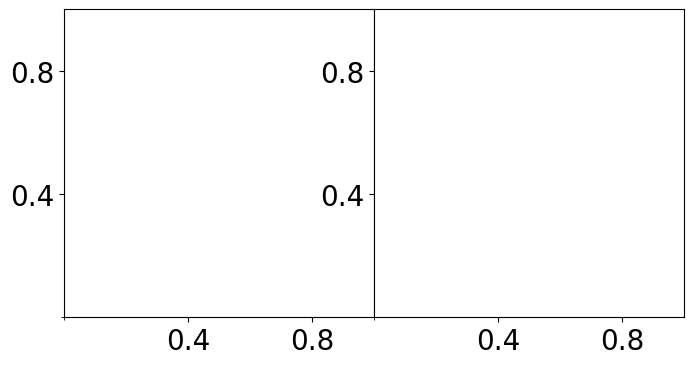

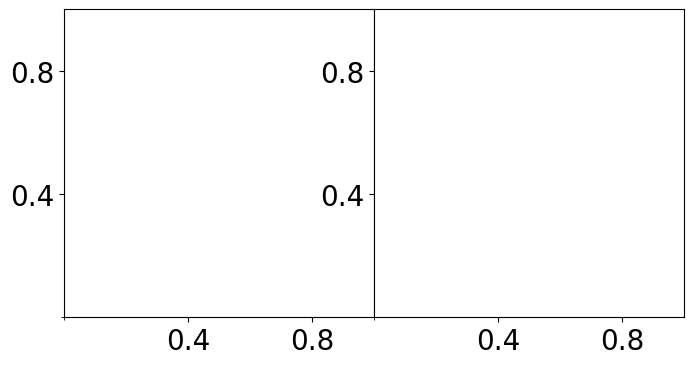

In [7]:
# ============================================================
# CREATE ANALYSIS AND RUN THE FIT
# ============================================================
# This is the main event: search.fit() explores the parameter
# space to find the posterior distribution.
#
# For ~14 parameters with n_live=100, expect:
#   - ~5-15 minutes on a modern laptop
#   - ~10,000-50,000 likelihood evaluations
#
# The search saves checkpoints, so you can interrupt and resume.
# ============================================================

analysis = al.AnalysisImaging(dataset=dataset)

print("Starting non-linear search...")
print(f"Free parameters: {model.total_free_parameters}")
print(f"Data pixels: {dataset.data.shape_slim}")
print("")

result = search.fit(model=model, analysis=analysis)

print("\n" + "=" * 50)
print("FIT COMPLETE")
print("=" * 50)

---

## 7. Interpreting Results: Posteriors and Diagnostics <a id="7-interpreting-results"></a>

### What the Result Contains

The `result` object stores:
- **`result.max_log_likelihood_instance`**: the single best-fit parameter set
- **`result.samples`**: the full posterior samples from the search
- **`result.max_log_likelihood_fit`**: the FitImaging object for the best fit
- **`result.info`**: summary string with all parameter values and uncertainties

In [8]:
# ============================================================
# RESULT SUMMARY
# ============================================================
# result.info gives a text summary of the maximum likelihood
# parameters and their 1σ uncertainties (from the posterior).
# ============================================================

print(result.info)

Bayesian Evidence                                                               6434.43799147
Maximum Log Likelihood                                                          6516.41734461

model                                                                           Collection (N=14)
    galaxies                                                                    Collection (N=14)
        lens - source                                                           Galaxy (N=7)
        lens
            mass                                                                Isothermal (N=5)
            shear                                                               ExternalShear (N=2)
        source
            bulge                                                               SersicCore (N=7)

Maximum Log Likelihood Model:

galaxies
    lens
        mass
            ell_comps
                ell_comps_0                                                     0.053
                ell_comps_1  

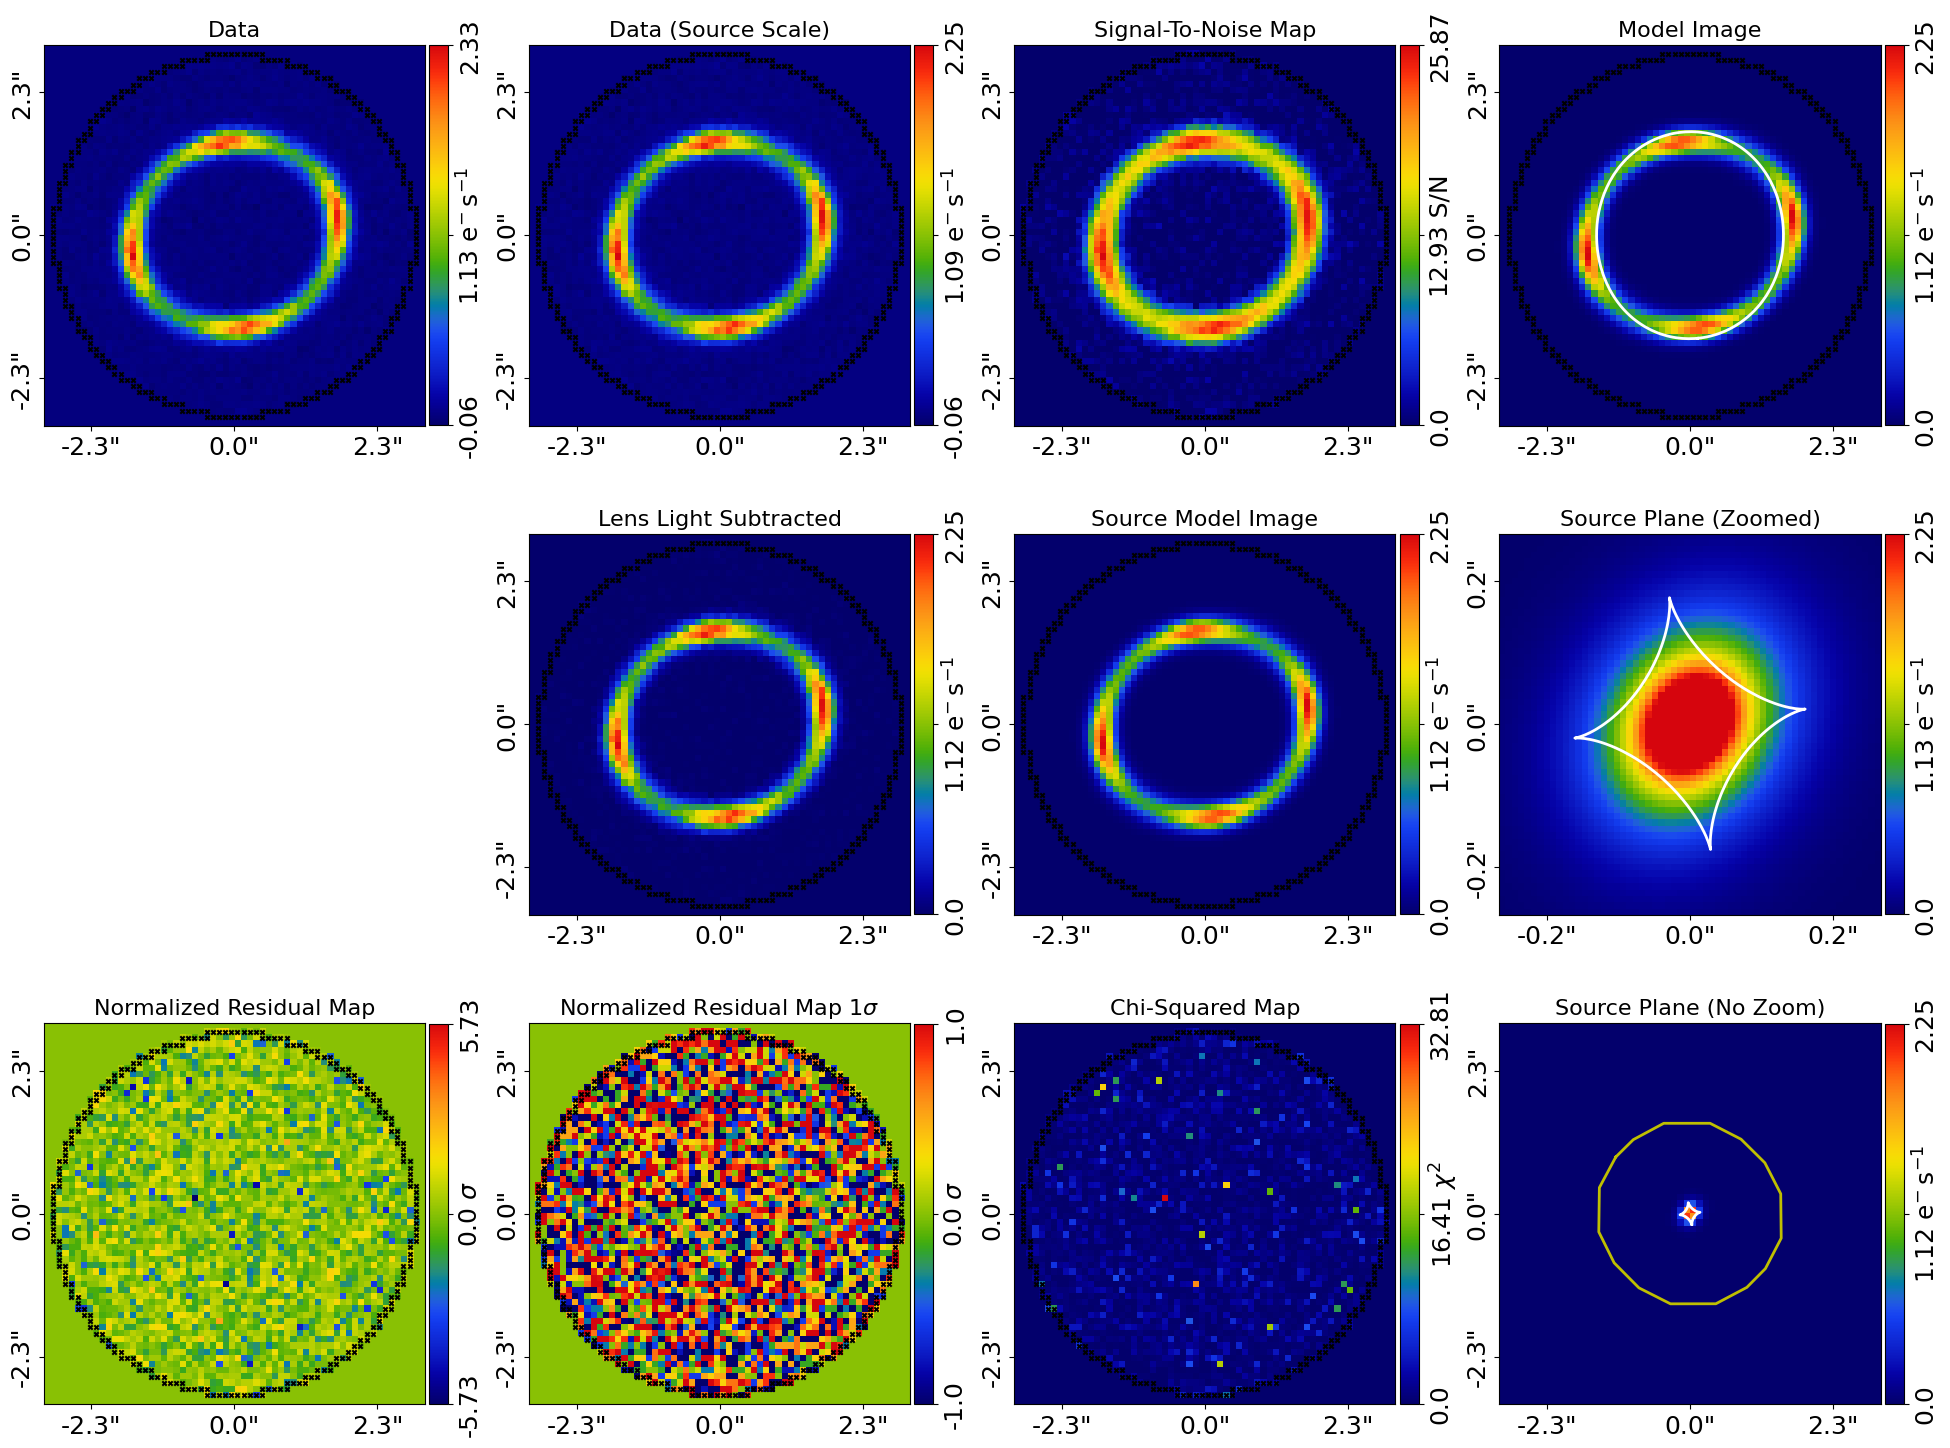

In [9]:
# ============================================================
# FIT QUALITY: RESIDUALS AND χ²
# ============================================================
# The subplot_fit shows:
#   - Data: the observed image
#   - Model: the best-fit PSF-convolved model image
#   - Residuals: data - model (should look like noise)
#   - Normalized residuals: (data - model) / σ (should be N(0,1))
#   - χ² map: residual² / σ² per pixel
#
# A good fit has:
#   - Residuals consistent with noise (no structure)
#   - Normalized residuals ~ N(0, 1)
#   - χ²_red ≈ 1
# ============================================================

fit_plotter = aplt.FitImagingPlotter(fit=result.max_log_likelihood_fit)
fit_plotter.subplot_fit()

2026-04-17 17:32:36,506 - root - WARNING - Too few points to create valid contours


2026-04-17 17:32:36,520 - root - WARNING - Too few points to create valid contours


2026-04-17 17:32:36,529 - root - WARNING - Too few points to create valid contours


2026-04-17 17:32:36,543 - root - WARNING - Too few points to create valid contours


2026-04-17 17:32:36,551 - root - WARNING - Too few points to create valid contours


...

2026-04-17 17:32:37,793 - root - WARNING - Too few points to create valid contours


2026-04-17 17:32:37,811 - root - WARNING - Too few points to create valid contours


2026-04-17 17:32:37,828 - root - WARNING - Too few points to create valid contours


2026-04-17 17:32:37,860 - root - WARNING - Too few points to create valid contours


2026-04-17 17:32:37,877 - root - WARNING - Too few points to create valid contours


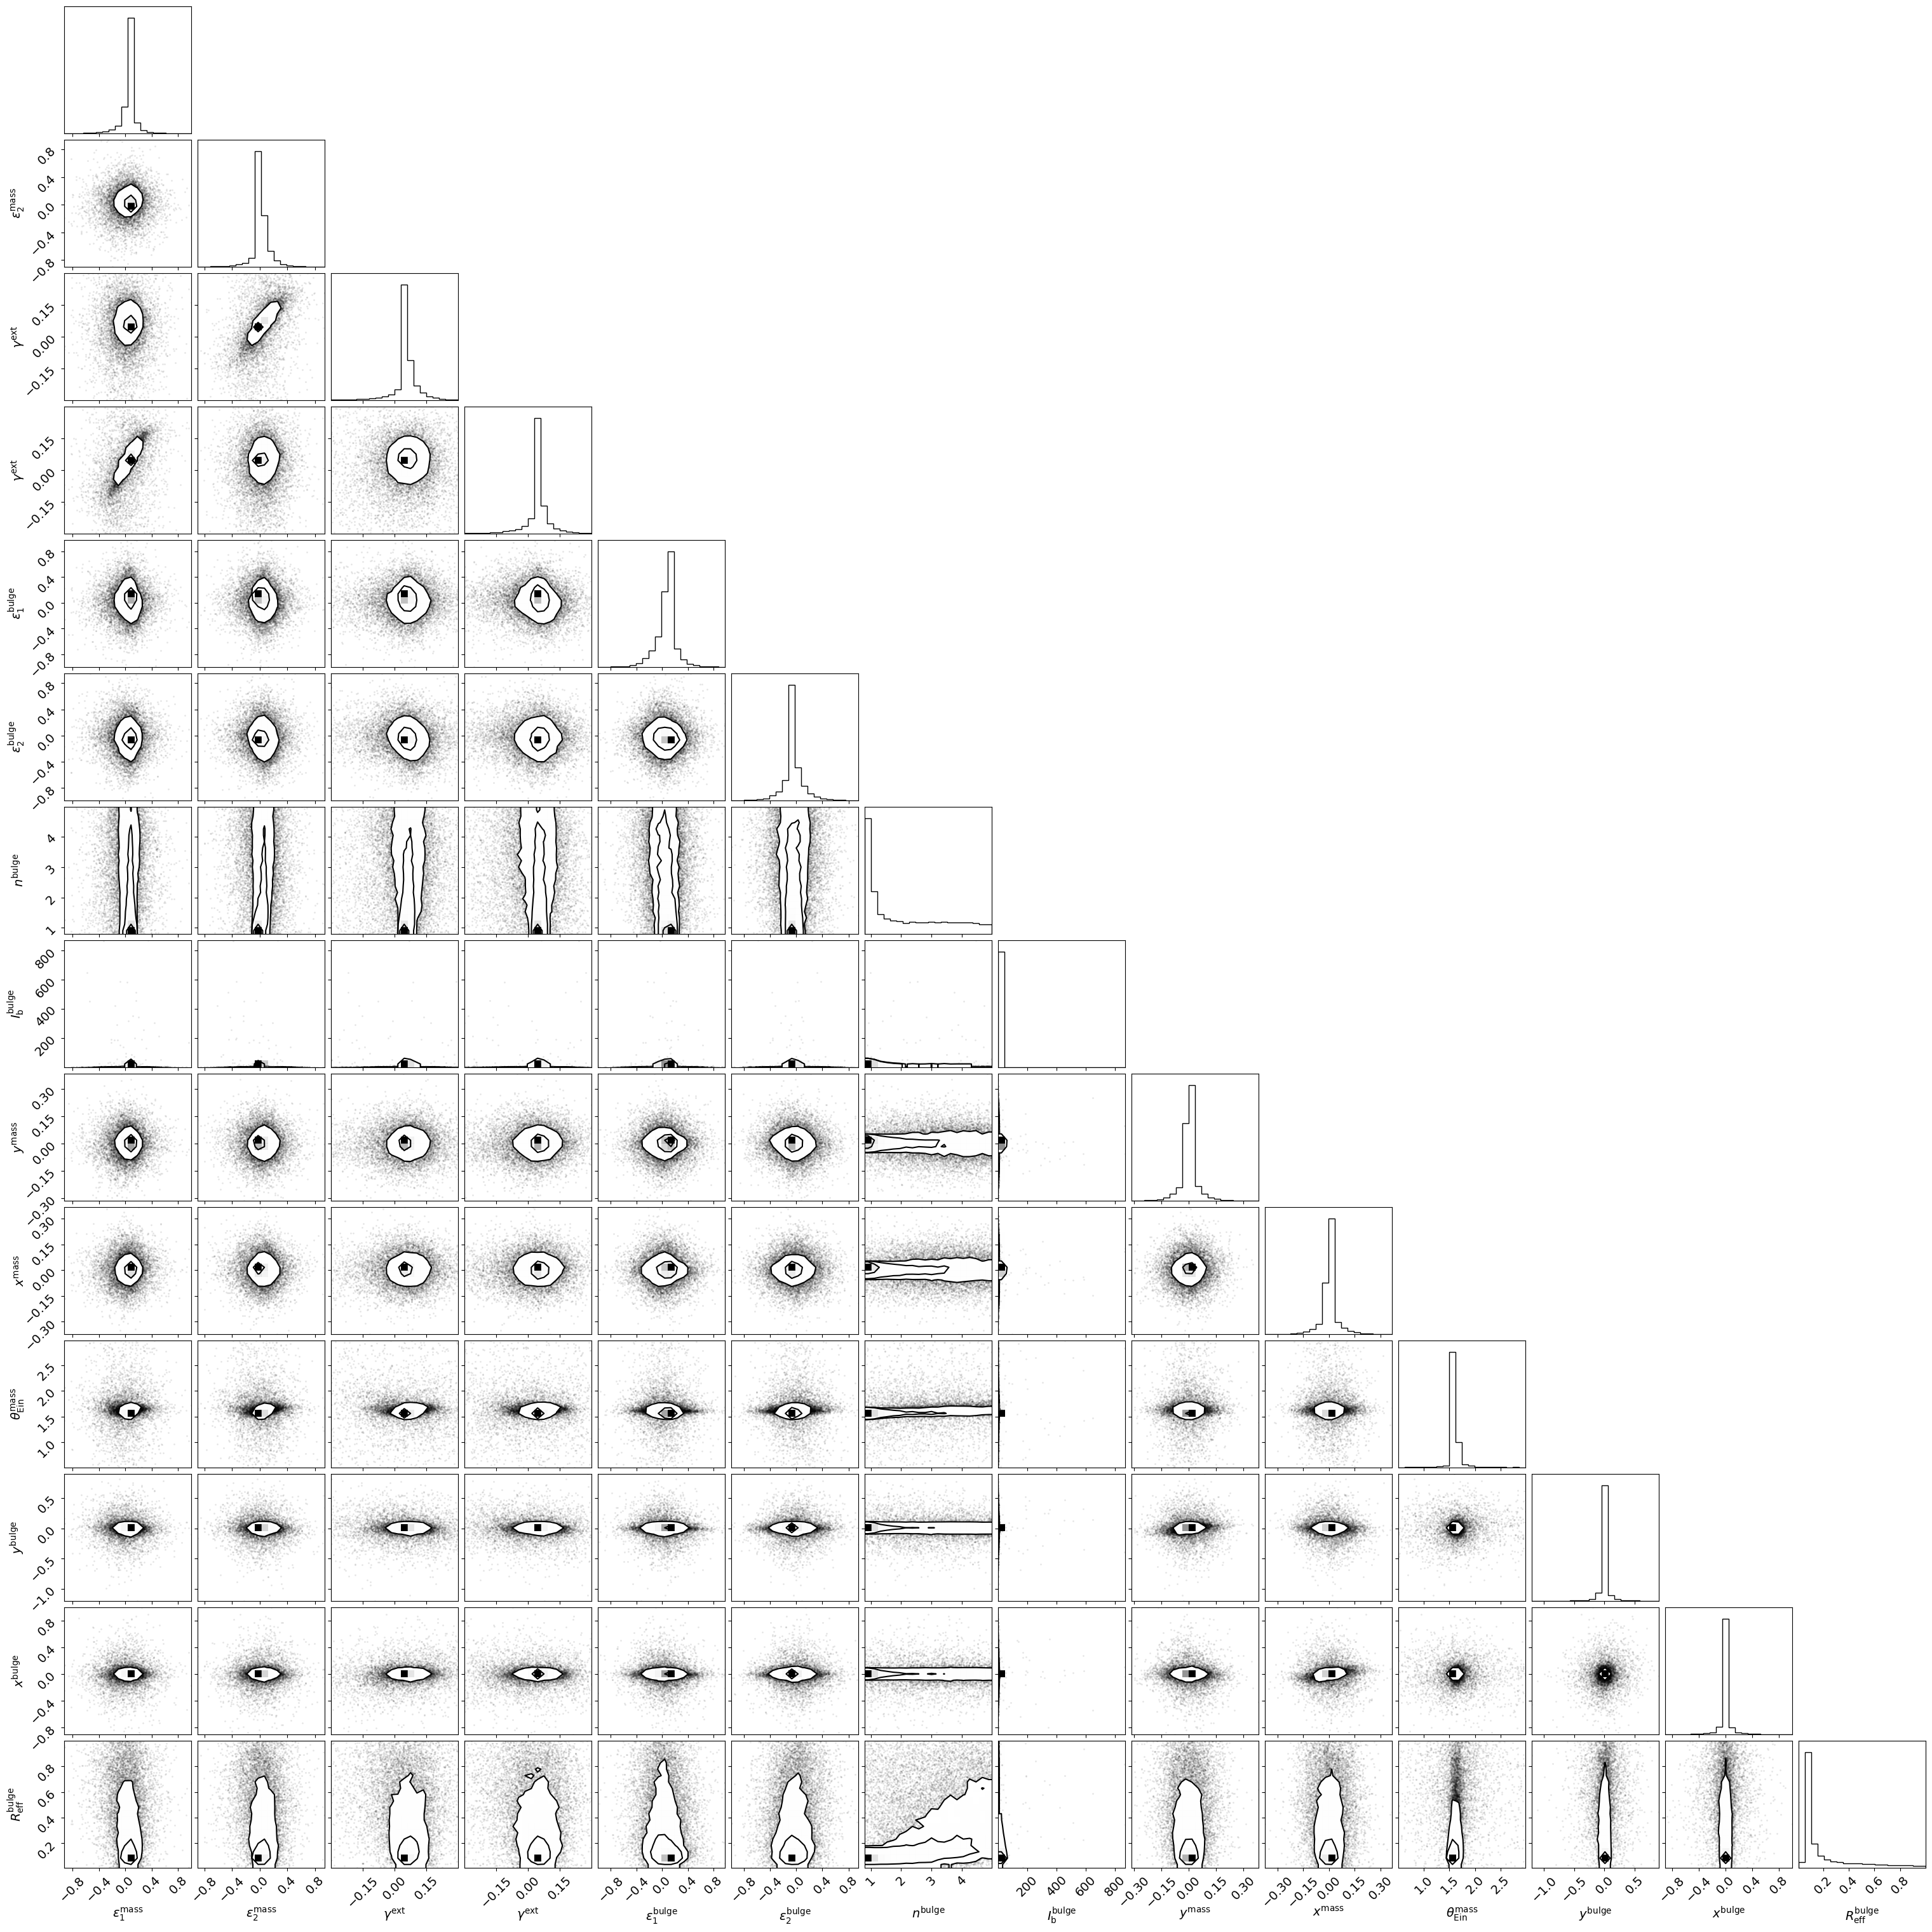

In [10]:
# ============================================================
# CORNER PLOT: THE POSTERIOR DISTRIBUTION
# ============================================================
# The corner plot shows the 1D and 2D marginal distributions
# of all parameters. Key things to look for:
#
# 1. Well-peaked 1D distributions → parameters are constrained
# 2. Elongated 2D contours → parameter degeneracies
#    (e.g., θ_E vs. source size is a classic degeneracy)
# 3. Multimodality → the data doesn't uniquely determine the model
# 4. Railing against priors → prior is too narrow or model is wrong
#
# We try corner_cornerpy first (most reliable), with anesthetic
# as an alternative.
# ============================================================

# Method 1: corner.py (standard, reliable)
try:
    plotter = aplt.NestPlotter(samples=result.samples)
    plotter.corner_cornerpy()
except Exception as e:
    print(f"corner_cornerpy failed: {e}")
    # Method 2: anesthetic (alternative)
    try:
        plotter.corner_anesthetic()
    except Exception as e2:
        print(f"corner_anesthetic also failed: {e2}")
        print("Install corner or anesthetic: pip install corner anesthetic")

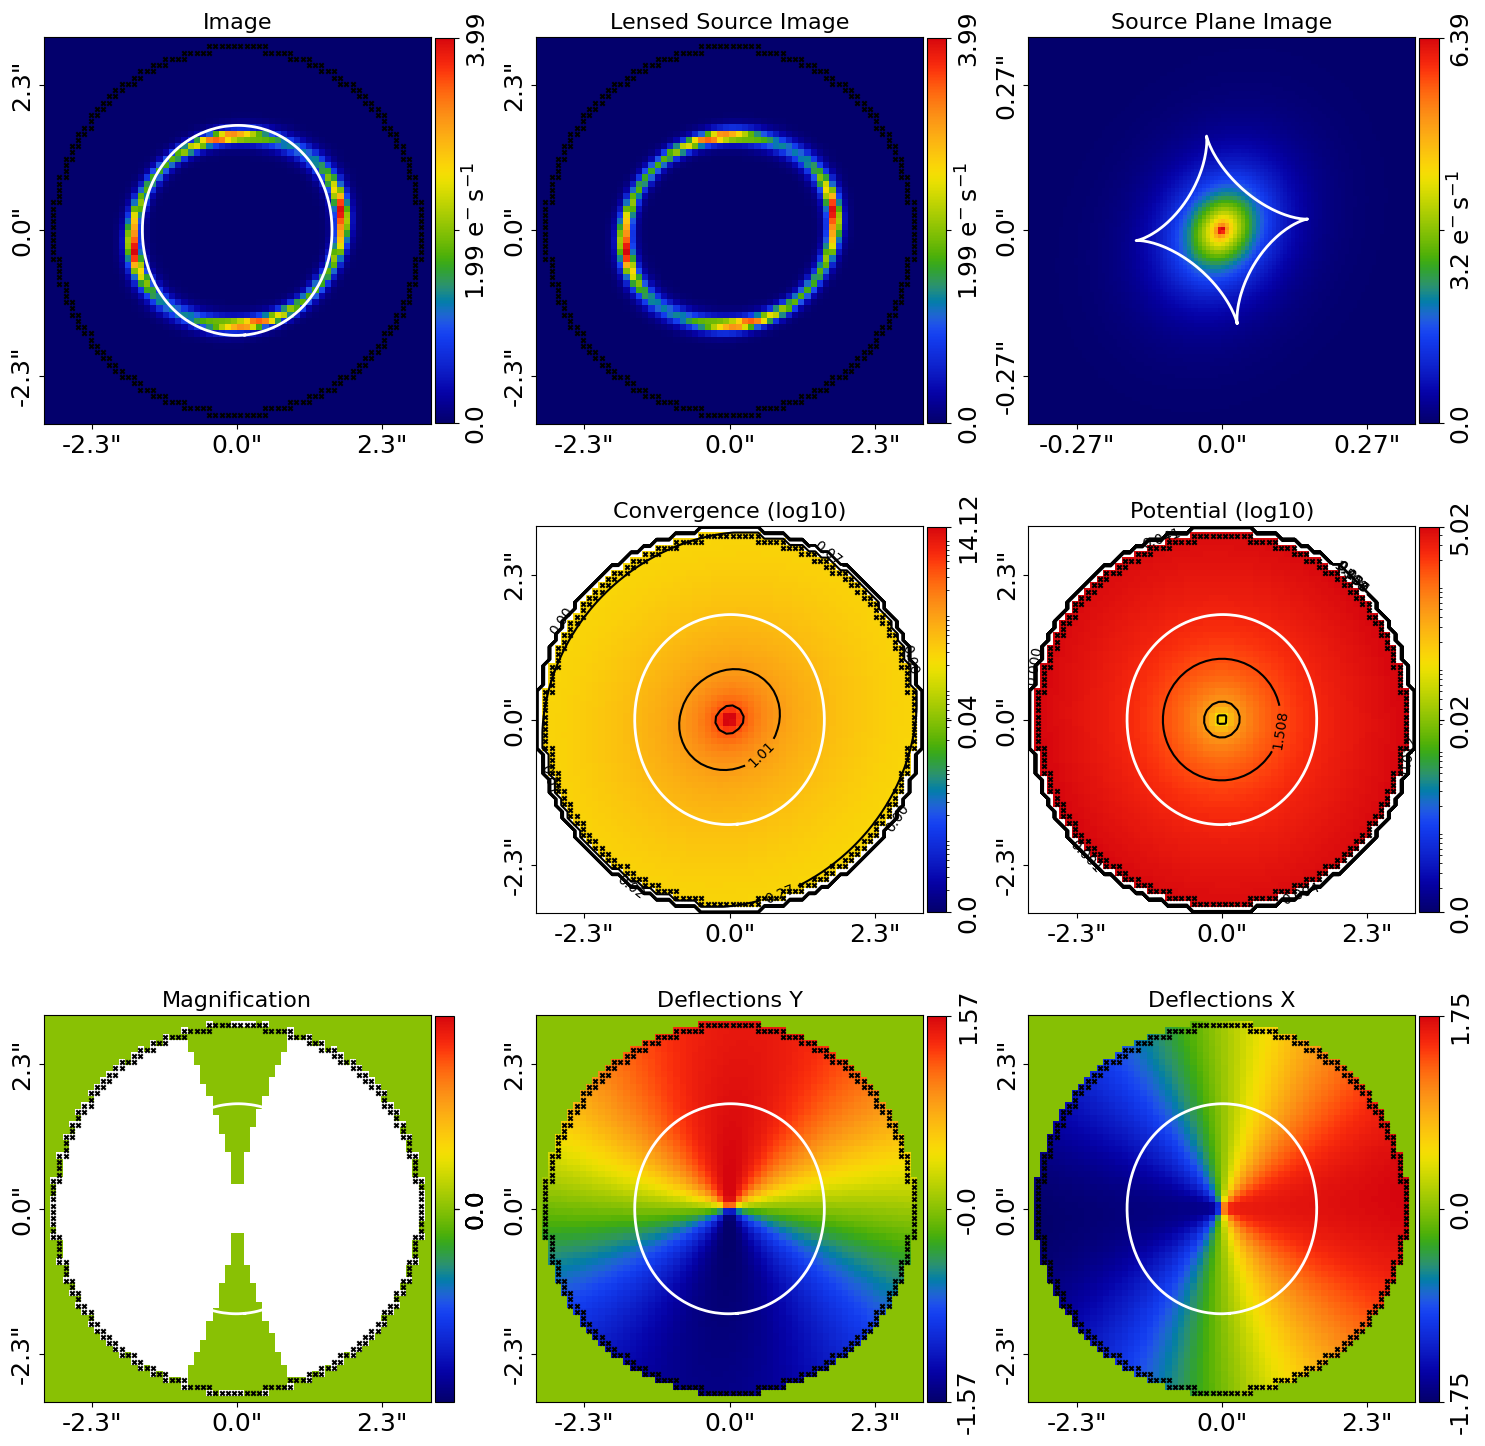

In [11]:
# ============================================================
# BEST-FIT TRACER: THE RECOVERED LENS MODEL
# ============================================================
# We can extract the best-fit Tracer and visualize the
# recovered lens model, including critical curves, caustics,
# and the source-plane reconstruction.
# ============================================================

tracer_plotter = aplt.TracerPlotter(
    tracer=result.max_log_likelihood_tracer,
    grid=result.grids.lp,
)
tracer_plotter.subplot_tracer()

In [12]:
# ============================================================
# EXTRACT KEY PARAMETERS
# ============================================================
# Access individual parameter values and their uncertainties
# from the posterior samples.
# ============================================================

# Maximum likelihood values
ml_instance = result.max_log_likelihood_instance

print("Maximum Likelihood Parameters:")
print(f"  θ_E = {ml_instance.galaxies.lens.mass.einstein_radius:.4f} arcsec")
print(f"  Lens centre = ({ml_instance.galaxies.lens.mass.centre[0]:.4f}, "
      f"{ml_instance.galaxies.lens.mass.centre[1]:.4f}) arcsec")
print(f"  γ₁ = {ml_instance.galaxies.lens.shear.gamma_1:.4f}")
print(f"  γ₂ = {ml_instance.galaxies.lens.shear.gamma_2:.4f}")
print(f"  Source centre = ({ml_instance.galaxies.source.bulge.centre[0]:.4f}, "
      f"{ml_instance.galaxies.source.bulge.centre[1]:.4f}) arcsec")
print(f"  Source R_e = {ml_instance.galaxies.source.bulge.effective_radius:.4f} arcsec")

Maximum Likelihood Parameters:
  θ_E = 1.6005 arcsec
  Lens centre = (0.0012, 0.0000) arcsec
  γ₁ = 0.0498
  γ₂ = 0.0504
  Source centre = (0.0005, -0.0000) arcsec
  Source R_e = 0.0984 arcsec


---

## 8. Common Pitfalls and Degeneracies <a id="8-common-pitfalls"></a>

### Key Degeneracies in Lens Modeling

1. **Mass-sheet degeneracy (MSD)**: Scaling the convergence as
   $\kappa' = \lambda\kappa + (1-\lambda)$ and the source as $\beta' = \lambda\beta$
   leaves the image unchanged (C&K Sec. 9.1). This is the fundamental degeneracy
   of strong lensing.

2. **Source size–magnification degeneracy**: A larger, fainter source with higher
   magnification can produce the same lensed image as a smaller, brighter source
   with lower magnification.

3. **Position angle–shear degeneracy**: Lens ellipticity and external shear produce
   similar distortions and are partially degenerate.

4. **Lens light–source light blending**: When the lens has light (Module 04+),
   separating lens and source emission becomes a major challenge.

### Practical Tips

- **Start simple**: fit simple models first (SIE + shear), then add complexity
- **Check residuals**: structure in residuals = model is wrong, not just noisy
- **Check priors**: if posteriors rail against prior bounds, widen them
- **Increase n_live**: if the search seems to miss the global optimum
- **Use search chaining** (Module 04): break complex models into stages

---

## 9. Exercises <a id="9-exercises"></a>

### Exercise 1: Fit Quality Assessment

Compute the reduced $\chi^2$ of the best fit:
```python
chi_squared = result.max_log_likelihood_fit.chi_squared
n_pixels = result.max_log_likelihood_fit.mask.pixels_in_mask
n_params = model.total_free_parameters
chi_squared_red = chi_squared / (n_pixels - n_params)
```
Is $\chi^2_{\rm red} \approx 1$? If not, what might be wrong?

### Exercise 2: Effect of Priors

Re-run the fit with very broad priors (e.g., $\theta_E \in [0.01, 10.0]$). Does the
search find the same solution? How many more iterations does it require?

### Exercise 3: Different Search Algorithms

Replace Nautilus with Emcee (MCMC):
```python
search = af.Emcee(
    path_prefix=Path("output") / "module_03",
    name="emcee_fit",
    nwalkers=30,
    nsteps=500,
)
```
Compare the posteriors. Are they consistent with Nautilus?

### Exercise 4: Model Comparison

Fit the same data with a simpler model (SIS instead of SIE — no ellipticity).
Compare the $\chi^2$ values and residuals. Does the SIS leave systematic residuals
that the SIE removes?

### Exercise 5: Parameter Recovery

Simulate your own dataset using Module 02 with known parameters, then fit it here.
Can you recover the input parameters within the 1σ posterior uncertainties? This is
the gold-standard test for any modeling pipeline.

---

## Summary

| Concept | Implementation | Theory |
|---------|---------------|--------|
| Bayesian inference | `search.fit(model, analysis)` | Bayes' theorem; C&K Ch. 8 |
| Model construction | `af.Model`, `af.Collection` | Parameter space |
| Priors | `af.UniformPrior`, `af.GaussianPrior` | Prior knowledge |
| Nested sampling | `af.Nautilus(n_live=100)` | Skilling (2004); Speagle (2020) |
| Likelihood | `al.AnalysisImaging` | $\chi^2$ statistic; Nightingale+18 eq. 3 |
| Posteriors | `result.samples`, corner plots | Marginal distributions |

**Next module:** Fitting 14 parameters at once is slow and can get stuck in local
minima. Module 04 introduces **search chaining** and the **SLaM pipeline** — the
strategy of breaking the fit into stages for robust, scalable modeling.

---

*Learning to Autolens — Module 03*
*Rodrigo Córdova Rosado, Harvard CfA*
*Built with Claude Code*